📢 **Atividade Prática: Classificação com Support Vector Machines (SVM)**

Dando continuidade aos nossos estudos práticos de Aprendizado de Máquina, nesta atividade vamos implementar e avaliar modelos de Support Vector Machines (SVM) para a tarefa de diagnóstico/classificação binária utilizando dados biomédicos reais.

📌 Contexto e Base de Dados
Utilizaremos o clássico conjunto de dados Breast Cancer Wisconsin (Diagnostic), disponível no Kaggle:


As características foram computadas a partir de imagens digitalizadas de biópsias por aspiração com agulha fina (FNA) de massas mamárias e descrevem aspectos dos núcleos celulares presentes na imagem. O objetivo é classificar os tumores em Malignos (M) ou Benignos (B).



🎯 Objetivos da Atividade

Exploração e Pré-processamento:

Realizar o carregamento e limpeza inicial dos dados (remoção de identificadores irrelevantes como id e tratamento de colunas vazias, se houver).

Codificar a variável alvo (diagnosis).

Atenção: Como o SVM é sensível à escala dos dados, realize a padronização/normalização dos atributos (ex.: StandardScaler). Buscar informações em fontes confiáveis sobre a padronização do tipo.

Modelagem com SVM:

- Separar o conjunto em treino e teste.

- Treinar modelos SVM testando diferentes funções de kernel (linear e RBF).

- Ajustar hiperparâmetros essenciais (como C e gamma).



In [65]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv


### 1. Importação das bibliotecas necessárias

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)

### 2. Leitura do dataset e exibição das primeiras linhas.

In [67]:
df = pd.read_csv('/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### 3. Tratamento dos dados e análise exploratória

O bloco abaixo remove a coluna de id que não é necessária para o modelo.

In [68]:
# Removendo o identificador
df.columns = df.columns.str.strip()

df = df.drop(columns=["id"])

print("Colunas encontradas:", df.columns.tolist())

Colunas encontradas: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [69]:
# Exibe informações gerais sobre as colunas numéricas
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [70]:
# Realiza a contagem de valores não nulos nas colunas
df.count()

diagnosis                  569
radius_mean                569
texture_mean               569
perimeter_mean             569
area_mean                  569
smoothness_mean            569
compactness_mean           569
concavity_mean             569
concave points_mean        569
symmetry_mean              569
fractal_dimension_mean     569
radius_se                  569
texture_se                 569
perimeter_se               569
area_se                    569
smoothness_se              569
compactness_se             569
concavity_se               569
concave points_se          569
symmetry_se                569
fractal_dimension_se       569
radius_worst               569
texture_worst              569
perimeter_worst            569
area_worst                 569
smoothness_worst           569
compactness_worst          569
concavity_worst            569
concave points_worst       569
symmetry_worst             569
fractal_dimension_worst    569
Unnamed: 32                  0
dtype: i

In [71]:
# Soma a quantidade de valores nulos nas colunas
df.isnull().sum()

diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed: 32                569
dtype: i

In [72]:
# Remoção da coluna "Unnamed: 32", pois está apenas com valores nulos.
df = df.drop(columns=["Unnamed: 32"])
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [73]:
# Para facilitar a definição das features, utilizamos o loop abaixo
feature_cols = [c for c in df.columns if c != "diagnosis"]

In [74]:
# Codificação da variável alvo ('diagnosis')
# M (Maligno) -> 1, B (Benigno) -> 0
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

In [75]:
# Codificando a variável alvo y (DIAGNOSIS) e as features (demais colunas)

X = df[feature_cols]
y = df['diagnosis']

In [76]:
# Exibe a quantidade de linhas e colunas de X e y
print(X.shape)
print(y.shape)

(569, 30)
(569,)


### 4. Separação em treino e teste

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [78]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nDistribuição em y_train:")
print(y_train.value_counts())
print("\nDistribuição em y_test:")
print(y_test.value_counts())

X_train: (455, 30)
X_test : (114, 30)

Distribuição em y_train:
diagnosis
0    286
1    169
Name: count, dtype: int64

Distribuição em y_test:
diagnosis
0    71
1    43
Name: count, dtype: int64


### 5. Experimento 1 — SVM Linear

O SVM busca o hiperplano que maximiza a margem entre as classes.
O StandardScaler é essencial pois o SVM é altamente sensível à escala.

In [79]:

pipeline_svm_linear = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=1.0, random_state=42)),
    ]
)

pipeline_svm_linear.fit(X_train, y_train)
y_pred_linear = pipeline_svm_linear.predict(X_test)


#### 5.1 Acurácia do SVM Linear

In [80]:
acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Acurácia do SVM linear: {acc_linear:.4f}")

print("\nRelatório de classificação — SVM linear\n")
print(
    classification_report(
        y_test, y_pred_linear, target_names=["Benigno", "Maligno"]
    )
)


Acurácia do SVM linear: 0.9561

Relatório de classificação — SVM linear

              precision    recall  f1-score   support

     Benigno       0.97      0.96      0.96        71
     Maligno       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



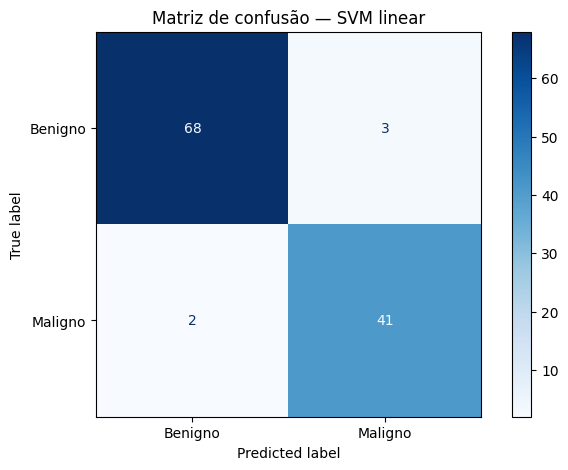

In [81]:
cm_linear = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=["Benigno", "Maligno"])

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusão — SVM linear")
plt.show()

#### 5.2 Testando diferentes hiperparâmetros para o SVM Linear: 

In [82]:
# Testando SVM linear com C=0.1
pipeline_linear_c01 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=0.1, random_state=42)),
])
pipeline_linear_c01.fit(X_train, y_train)
y_pred_linear_c01 = pipeline_linear_c01.predict(X_test)
print(f"Linear, C=0.1 -> Acurácia: {accuracy_score(y_test, y_pred_linear_c01):.4f}")

Linear, C=0.1 -> Acurácia: 0.9825


In [83]:
# Testando SVM linear com C=10
pipeline_linear_c10 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=10, random_state=42)),
])
pipeline_linear_c10.fit(X_train, y_train)
y_pred_linear_c10 = pipeline_linear_c10.predict(X_test)
print(f"Linear, C=10 -> Acurácia: {accuracy_score(y_test, y_pred_linear_c10):.4f}")

Linear, C=10 -> Acurácia: 0.9649


In [84]:
# Validação cruzada com 5 folds
scores_linear = cross_val_score(pipeline_svm_linear, X, y, cv=5)
print("Acurácia em cada fold (CV):", scores_linear)
print(f"Média: {scores_linear.mean():.4f}")
print(f"Desvio-padrão: {scores_linear.std():.4f}")

Acurácia em cada fold (CV): [0.96491228 0.98245614 0.96491228 0.96491228 0.98230088]
Média: 0.9719
Desvio-padrão: 0.0086


### 6. Experimento 2 — SVM Não Linear (Kernel RBF)

O kernel RBF (Função de Base Radial) ajusta fronteiras de decisão complexas e curvas.

In [85]:
pipeline_svm_rbf = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
        ),  # C e gamma controlam margem e alcance
    ]
)

pipeline_svm_rbf.fit(X_train, y_train)
y_pred_rbf = pipeline_svm_rbf.predict(X_test)

#### 6.1 Acurácia do SVM RBF

In [86]:
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Acurácia do SVM com kernel RBF: {acc_rbf:.4f}")

print("\nRelatório de classificação — SVM com kernel RBF\n")
print(
    classification_report(
        y_test, y_pred_rbf, target_names=["Benigno", "Maligno"]
    )
)

Acurácia do SVM com kernel RBF: 0.9825

Relatório de classificação — SVM com kernel RBF

              precision    recall  f1-score   support

     Benigno       0.97      1.00      0.99        71
     Maligno       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



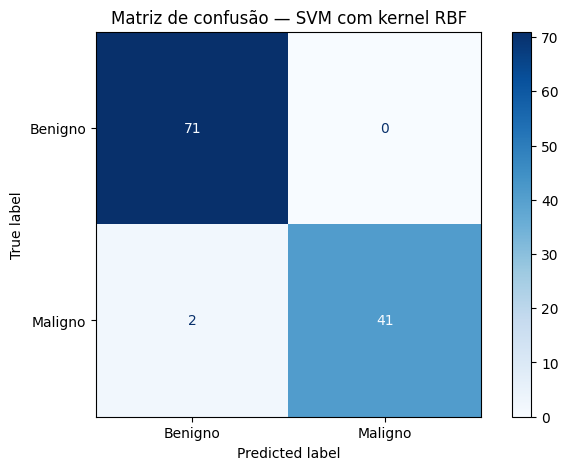

In [87]:

cm_rbf = confusion_matrix(y_test, y_pred_rbf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rbf, display_labels=["Benigno", "Maligno"]
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusão — SVM com kernel RBF")
plt.show()

In [88]:
# Validação cruzada com 5 folds
scores_rbf = cross_val_score(pipeline_svm_rbf, X, y, cv=5)
print("Acurácia em cada fold (CV):", scores_rbf)
print(f"Média: {scores_rbf.mean():.4f}")
print(f"Desvio-padrão: {scores_rbf.std():.4f}")

Acurácia em cada fold (CV): [0.97368421 0.95614035 1.         0.96491228 0.97345133]
Média: 0.9736
Desvio-padrão: 0.0147


#### 6.2 Testando diferentes hiperparâmetros para o SVM Não Linear: 

In [89]:
# Testando C=0.1
pipeline_c01 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=0.1, gamma="scale", random_state=42)),
])
pipeline_c01.fit(X_train, y_train)
y_pred_c01 = pipeline_c01.predict(X_test)
print(f"C=0.1, gamma=scale -> Acurácia: {accuracy_score(y_test, y_pred_c01):.4f}")

C=0.1, gamma=scale -> Acurácia: 0.9474


In [90]:
# Testando C=10
pipeline_c10 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale", random_state=42)),
])
pipeline_c10.fit(X_train, y_train)
y_pred_c10 = pipeline_c10.predict(X_test)
print(f"C=10, gamma=scale -> Acurácia: {accuracy_score(y_test, y_pred_c10):.4f}")

C=10, gamma=scale -> Acurácia: 0.9737


In [91]:
# Testando gamma=0.01
pipeline_gamma_baixo = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma=0.01, random_state=42)),
])
pipeline_gamma_baixo.fit(X_train, y_train)
y_pred_gamma_baixo = pipeline_gamma_baixo.predict(X_test)
print(f"C=1.0, gamma=0.01 -> Acurácia: {accuracy_score(y_test, y_pred_gamma_baixo):.4f}")

C=1.0, gamma=0.01 -> Acurácia: 0.9649


### 7. Tabela Comparativa de Desempenho

In [92]:
comparacao = pd.DataFrame(
    {
        "Modelo": ["SVM linear", "SVM não linear (RBF)"],
        "Acurácia no teste": [acc_linear, acc_rbf],
        "Acurácia média CV": [scores_linear.mean(), scores_rbf.mean()],
        "Desvio-padrão CV": [scores_linear.std(), scores_rbf.std()],
    }
)

display(comparacao)

,Modelo,Acurácia no teste,Acurácia média CV,Desvio-padrão CV
0,SVM linear,0.956140,0.971899,0.008557
1,SVM não linear (RBF),0.982456,0.973638,0.014679


### 8. Conclusão


Neste trabalho, dois modelos SVM foram treinados para classificar tumores de mama em Malignos ou Benignos, utilizando o dataset Breast Cancer Wisconsin. Antes do treinamento, os dados foram limpos (remoção das colunas `id` e `Unnamed: 32`), a variável alvo foi codificada numericamente com 0 e 1 e as features foram padronizadas com `StandardScaler`, etapa essencial já que o SVM é sensível à escala dos atributos.

O modelo com kernel linear obteve acurácia de **0.95** no conjunto de teste e média de **0.97** na validação cruzada de 5 folds. Já o modelo com kernel RBF obteve acurácia de **0.98** e média de **0.97** na validação cruzada.

O ajuste manual de hiperparâmetros mostrou que a combinação C=10, gamma="scale" produziu o melhor resultado, com acurácia de **0.9737**. Porém, o ajuste manual não superou o padrão adotado para este projeto, que foi C=1.0 e gamma="scale".

Comparando os dois kernels, o modelo RBF apresentou desempenho levemente superior neste dataset, o que é esperado.